In [4]:
import pandas as pd
import numpy as np

In [9]:
data = pd.read_csv('data_studentlist.csv')

In [10]:
df = data.copy()

In [25]:
df.head()

,Name,Gender,Age,Grade,Absence,Bloodtype,Height,Weight
0,Jared Diamond,M,23,3,Y,O,165.3,68.2
1,Sarah O'Donnel,F,22,2,N,AB,170.1,53.0
2,Brian Martin,M,24,4,N,B,175.0,80.1
3,David Hassel,M,23,3,N,AB,182.1,85.7
4,Clara Rodriquez,F,20,1,Y,A,168.0,49.5


In [13]:
df[df['Gender'] == 'M']['Height'].mean() #1

np.float64(172.41000000000003)

In [16]:
df[df['Gender'] == 'F']['Height'].mean() #2

np.float64(166.64285714285714)

In [18]:
df[df['Gender'] == 'M']['Weight'].mean() #3

np.float64(68.50000000000001)

In [19]:
df[df['Gender'] == 'F']['Weight'].mean() #4

np.float64(50.44285714285714)

In [20]:
df[df['Gender'] == 'M']['Height'].max() #5

182.1

In [21]:
df[df['Gender'] == 'F']['Height'].min() #6

155.2

In [22]:
df[(df['Gender'] == 'M') & (df['Height'] > 175)]['Weight'].min() #7

61.3

In [23]:
df[(df['Gender'] == 'F') & (df['Height'] < 160)]['Weight'].max() #8

45.3

In [24]:
df[df['Absence'] == 'N']['Grade'].mean() #9

np.float64(2.076923076923077)

In [26]:
df[df['Absence'] == 'Y']['Grade'].mean() # 10

np.float64(3.0)

In [29]:
df[df['Bloodtype'].isin(['A', 'AB'])]['Height'].mean() #11

np.float64(172.64285714285714)

In [30]:
df[(df['Gender'] == 'M') & (df['Bloodtype'].isin(['A', 'AB']))]['Height'].mean() #12

np.float64(173.375)

In [31]:
df[(df['Absence'] == 'Y') & (df['Grade'] >= 3)]['Age'].mean() #13

np.float64(23.666666666666668)

In [32]:
df2 = pd.read_csv('data_census.csv')
df2.head()

,Province Code,City Code,Population,Households,Person's Household,Gender Ratio
0,109,1001,"10,078,850","4,197,478",2.40,0.97
1,109,1188,"155,695","72,882",2.14,0.98
2,109,1189,"126,817","59,614",2.13,1.00
3,109,1158,"235,186","108,138",2.17,0.94
4,109,1105,"298,145","126,915",2.35,0.99


In [35]:
df2[df2['Province Code'].isin([115, 116])]['Population'].sum() #1

' 2,068,444  602,939  260,326  342,613  112,282  104,738  295,751  168,415  124,542  40,052  164,121  54,990  71,388  57,198  32,191  92,766  84,158  62,913  615,250  454,673  160,577 '

In [39]:
df2['Population'] = df2['Population'].str.replace(',', '').astype(int)
df2[df2['Gender Ratio'] > 1]['Population'].mean() #2

np.float64(419221.2076923077)

In [41]:
df2[(df2['Gender Ratio'] > 1) & (df2["Person's Household"] < 2)] #3

,Province Code,City Code,Population,Households,Person's Household,Gender Ratio
62,112,1155,20825,"11,172",1.86,1.29
149,101,1240,26790,"13,433",1.99,1.27
152,101,1017,30066,"15,485",1.94,1.15
167,117,1033,38027,"19,145",1.99,1.03
227,113,1120,43566,"22,248",1.96,1.11
253,104,1163,10304,"5,365",1.92,1.15


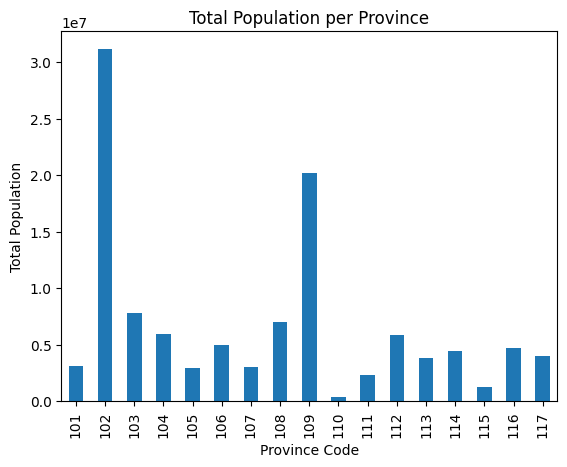

In [42]:
import matplotlib.pyplot as plt
prov_pop = df2.groupby('Province Code')['Population'].sum() #4
plt.figure()
prov_pop.plot(kind='bar')
plt.xlabel('Province Code')
plt.ylabel('Total Population')
plt.title('Total Population per Province')
plt.show()

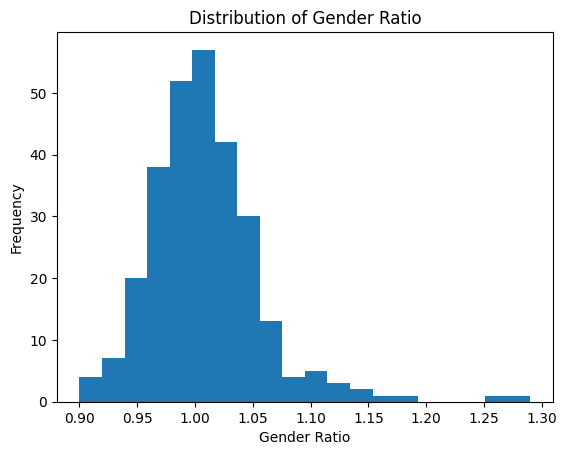

In [44]:
plt.figure() #5
df2['Gender Ratio'].plot(kind='hist', bins=20)
plt.xlabel('Gender Ratio')
plt.title('Distribution of Gender Ratio')
plt.show()

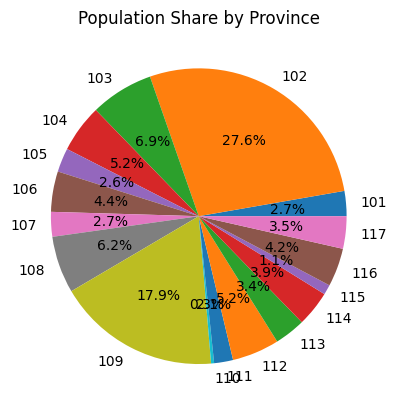

In [45]:
share = prov_pop / prov_pop.sum() * 100
plt.figure()
share.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Population Share by Province')
plt.show()

In [46]:
df3 = pd.read_csv('data_sales.csv')
df3.head()

,Date,Region,Item,Unit Price,Units
0,04-Jul-14,East,Pen Set,4.99,62
1,12-Jul-14,East,Binder,1.99,29
2,21-Jul-14,Central,Pen Set,12.49,55
3,29-Jul-14,East,Binder,19.99,81
4,07-Aug-14,Central,Pen Set,23.95,42


In [65]:
df3['Amount'] = df3['Unit Price'] * df3['Units'] #1
display(df3.head())

,Date,Region,Item,Unit Price,Units,Amount
0,04-Jul-14,East,Pen Set,4.99,62,309.38
1,12-Jul-14,East,Binder,1.99,29,57.71
2,21-Jul-14,Central,Pen Set,12.49,55,686.95
3,29-Jul-14,East,Binder,19.99,81,1619.19
4,07-Aug-14,Central,Pen Set,23.95,42,1005.90


In [64]:
df3.groupby('Region')['Unit Price'].mean() #2

,Unit Price
Region,
Central,18.018750
East,9.143846
West,53.658333


In [63]:
df3.pivot_table(index='Region', values='Unit Price', aggfunc='mean') #3

,Unit Price
Region,
Central,18.018750
East,9.143846
West,53.658333


In [62]:
df3.groupby('Region')[['Unit Price', 'Units']].mean() #4

,Unit Price,Units
Region,,
Central,18.018750,49.958333
East,9.143846,53.153846
West,53.658333,38.500000


In [61]:
df3.pivot_table(index='Region', values=['Unit Price', 'Units'], aggfunc='mean') #5

,Unit Price,Units
Region,,
Central,18.018750,49.958333
East,9.143846,53.153846
West,53.658333,38.500000


In [60]:
df3.pivot_table(index='Region', columns='Item', values='Units', aggfunc='sum', fill_value=0) #6

Item,Binder,Desk,Pen,Pen Set,Pencil
Region,,,,,
Central,424,7,27,243,498
East,234,0,175,152,130
West,64,3,76,0,88


In [74]:
df3.pivot_table(index='Region', columns='Item', values='Amount', aggfunc='sum', fill_value=0) #7


Item,Binder,Desk,Pen,Pen Set,Pencil
Region,,,,,
Central,5762.63,875.0,539.73,2421.39,1540.32
East,2535.66,0.0,1354.25,1748.48,363.70
West,1279.36,825.0,151.24,0.00,231.12


In [66]:
df4 = pd.read_csv('data_coffeeshop.csv')
df4.head()

,Year of Start,Current State,Size of Site
0,2008.0,In,20.80
1,2010.0,In,212.72
2,2013.0,In,20.04
3,2012.0,In,64.17
4,2002.0,Out,11.40


In [70]:
df4_cleaned = df4.dropna(subset=['Year of Start']).copy()
df4_cleaned['Year of Start'] = df4_cleaned['Year of Start'].astype(int)
year_frequency = df4_cleaned['Year of Start'].value_counts().sort_index()
display(year_frequency.head())

,count
Year of Start,
1964,2
1966,2
1967,3
1968,1
1969,2


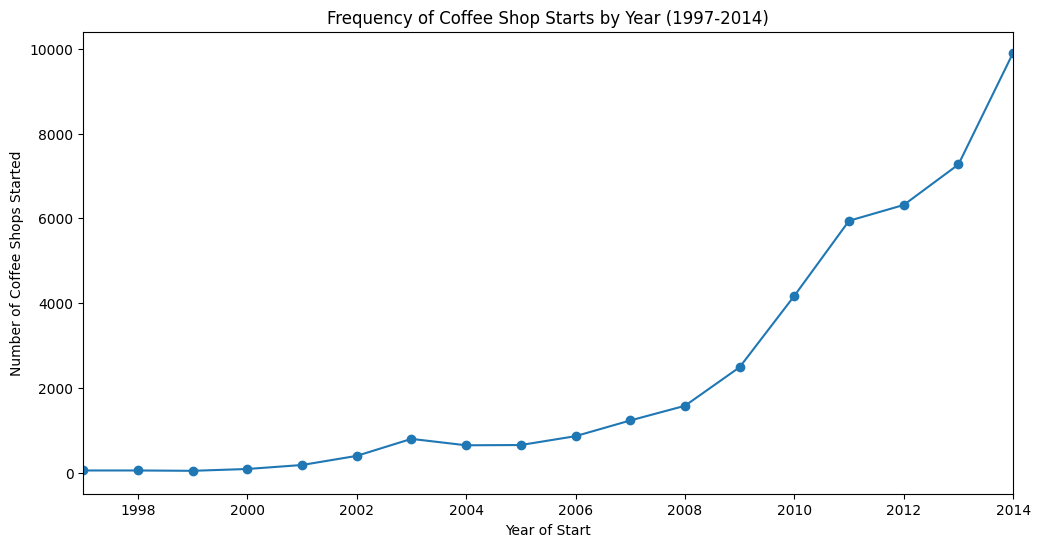

In [77]:

plt.figure(figsize=(12, 6))
plt.plot(year_frequency.index, year_frequency.values, marker='o')
plt.title('Frequency of Coffee Shop Starts by Year (1997-2014)')
plt.xlabel('Year of Start')
plt.ylabel('Number of Coffee Shops Started')
plt.xlim(1997, 2014)
plt.show()

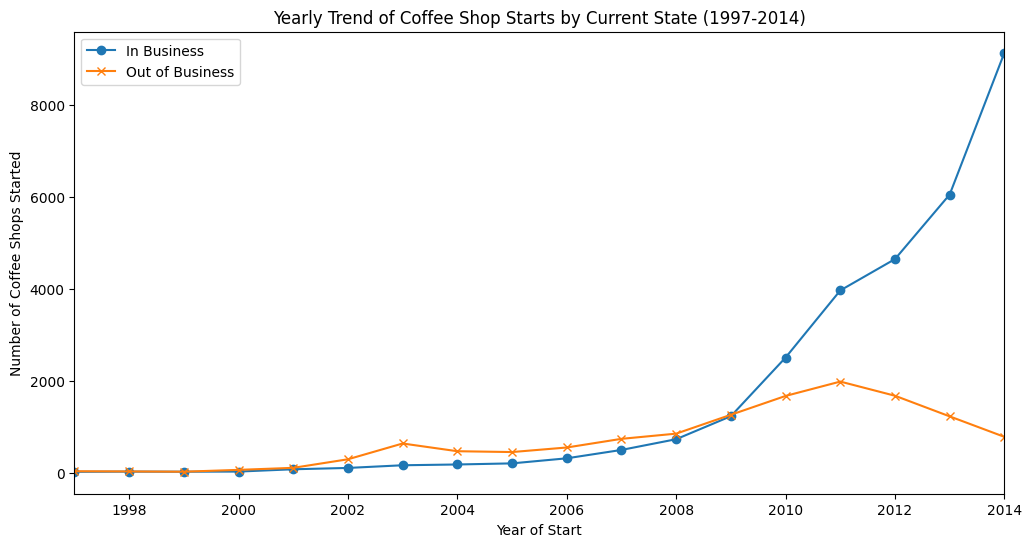

In [78]:

df_in = df4_cleaned[df4_cleaned['Current State'] == 'In']
df_out = df4_cleaned[df4_cleaned['Current State'] == 'Out']
year_frequency_in = df_in['Year of Start'].value_counts().sort_index()
year_frequency_out = df_out['Year of Start'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(year_frequency_in.index, year_frequency_in.values, marker='o', label='In Business')
plt.plot(year_frequency_out.index, year_frequency_out.values, marker='x', label='Out of Business')
plt.title('Yearly Trend of Coffee Shop Starts by Current State (1997-2014)')
plt.xlabel('Year of Start')
plt.ylabel('Number of Coffee Shops Started')
plt.xlim(1997, 2014)
plt.legend()
plt.show()